# Medical Document Extraction Playground — Selected Samples Flow Test

This notebook is for **testing the extraction flow on your selected samples before changing backend/code with Codex**.

It does **not call the API** and does **not use database/storage**. It imports the current repository services directly and lets you inspect every stage:

1. sample discovery and preview
2. validation
3. document analysis
4. quality check
5. rendering / preprocessing
6. OCR
7. relevance
8. classification
9. common fields
10. lab / radiology / Pap extraction
11. full pipeline output
12. selected-sample batch evaluation
13. notebook-only OCR variant experiments for phone photos

Use this notebook to decide exactly what should be changed in the core extraction code.


## 0. Important usage notes

Put this notebook inside the repository, preferably:

```text
notebooks/extraction_selected_samples_flow_test.ipynb
```

Your selected sample folder can be one of:

```text
samples/selected samples/
samples/raw/
samples/
```

The notebook supports PDF, JPG, JPEG, PNG, and WEBP files, including Persian filenames and spaces in folder names.


In [21]:
from __future__ import annotations

import os
import re
import json
import csv
import math
import uuid
import shutil
import tempfile
from pathlib import Path
from typing import Any

SUPPORTED_EXTS = {'.pdf', '.jpg', '.jpeg', '.png', '.webp'}

# Change this if your notebook is outside the repository.
# The auto-detection below searches upward for app/services/extraction_pipeline.py.
def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for p in [start] + list(start.parents):
        if (p / 'app' / 'services' / 'extraction_pipeline.py').exists():
            return p
    raise RuntimeError('Could not find repository root. Open the notebook from inside the repository or set REPO_ROOT manually.')

REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)
print('REPO_ROOT =', REPO_ROOT)


REPO_ROOT = /Users/aliebrahimi/Documents/Saman Salamat/Extract text from files/Extract-text-from-medical-documents


In [22]:
# Make repository imports available.
import sys
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from app.services.extraction_pipeline import ExtractionPipeline, ExtractionInput
from app.services.file_validation_service import FileValidationService, SUPPORTED, MIME_ALIASES
from app.services.document_analysis_service import DocumentAnalysisService
from app.services.quality_service import QualityService
from app.services.preprocessing_service import PreprocessingService
from app.services.ocr_service import OCRService, OCRResult, OCRPageResult
from app.services.relevance_service import RelevanceService, normalize_persian, normalize_digits
from app.services.classification_service import ClassificationService
from app.services.common_field_extractor import CommonFieldExtractor
from app.services.lab_extractor import LabExtractor
from app.services.radiology_extractor import RadiologyExtractor
from app.services.pap_smear_extractor import PapSmearExtractor
from app.dictionaries.lab_test_aliases import LAB_TEST_ALIASES

print('Imports OK')


Imports OK


## 1. Find selected sample files

This cell scans your selected sample folders and lists real files only. It will never select a folder as input.


In [35]:
SAMPLE_DIR_CANDIDATES = [
    REPO_ROOT / 'samples' / 'selected samples',
    #REPO_ROOT / 'samples' / 'raw',
    #REPO_ROOT / 'samples',
    Path('/mnt/data'),
]

sample_files: list[Path] = []
for folder in SAMPLE_DIR_CANDIDATES:
    if not folder.exists() or not folder.is_dir():
        continue
    for p in folder.rglob('*'):
        if p.is_file() and p.suffix.lower() in SUPPORTED_EXTS:
            sample_files.append(p.resolve())

# Deduplicate while preserving order.
seen = set()
unique_files = []
for p in sample_files:
    if p not in seen:
        unique_files.append(p)
        seen.add(p)
sample_files = unique_files

print(f'Found {len(sample_files)} sample files')
for i, p in enumerate(sample_files[:100]):
    rel = p.relative_to(REPO_ROOT) if str(p).startswith(str(REPO_ROOT)) else p
    print(f'{i:03d} | {p.suffix.lower():5s} | {p.stat().st_size/1024:8.1f} KB | {rel}')

assert sample_files, 'No sample files found. Put PDFs/images in samples/selected samples or samples/raw.'


Found 20 sample files
000 | .jpg  |     58.2 KB | samples/selected samples/20260427_181919.jpg
001 | .jpg  |     56.8 KB | samples/selected samples/۲۰۲۶۰۴۲۸_۱۵۰۱۰۶.jpg
002 | .pdf  |     44.2 KB | samples/selected samples/0014161672_14041209_O_00404121721.pdf
003 | .jpg  |    148.6 KB | samples/selected samples/۲۰۲۶۰۴۲۵_۲۲۰۷۰۰.jpg
004 | .jpg  |     44.2 KB | samples/selected samples/20260427_181713.jpg
005 | .pdf  |     42.9 KB | samples/selected samples/0021858845_14041209_O_00404121731.pdf
006 | .jpg  |     42.0 KB | samples/selected samples/-2147483648_-210195.jpg
007 | .pdf  |     40.8 KB | samples/selected samples/0023471026_14041209_O_00404121728.pdf
008 | .pdf  |     41.2 KB | samples/selected samples/0025631314_14041209_O_00404121726.pdf
009 | .jpg  |     77.8 KB | samples/selected samples/-2147483648_-210193.jpg
010 | .jpg  |    123.6 KB | samples/selected samples/۲۰۲۶۰۴۲۸_۱۵۰۲۲۸.jpg
011 | .pdf  |     44.1 KB | samples/selected samples/0024150010_14041209_O_00404121722.pdf
012 

## 2. Choose one sample file

Set `SAMPLE_INDEX` to any row from the list above. The notebook checks that the selected input is a real file, not a directory.


In [36]:
SAMPLE_INDEX = 0  # change this number
SAMPLE_FILE = sample_files[SAMPLE_INDEX]

assert SAMPLE_FILE.exists(), f'Missing file: {SAMPLE_FILE}'
assert SAMPLE_FILE.is_file(), f'SAMPLE_FILE must be a file, not a folder: {SAMPLE_FILE}'
assert SAMPLE_FILE.suffix.lower() in SUPPORTED_EXTS, f'Unsupported extension: {SAMPLE_FILE.suffix}'

print('Selected file:')
print(SAMPLE_FILE)
print('Size KB:', round(SAMPLE_FILE.stat().st_size/1024, 1))


Selected file:
/Users/aliebrahimi/Documents/Saman Salamat/Extract text from files/Extract-text-from-medical-documents/samples/selected samples/20260427_181919.jpg
Size KB: 58.2


## 3. Preview selected file

For PDFs, this renders the first page. For images, it displays the image after EXIF orientation correction.


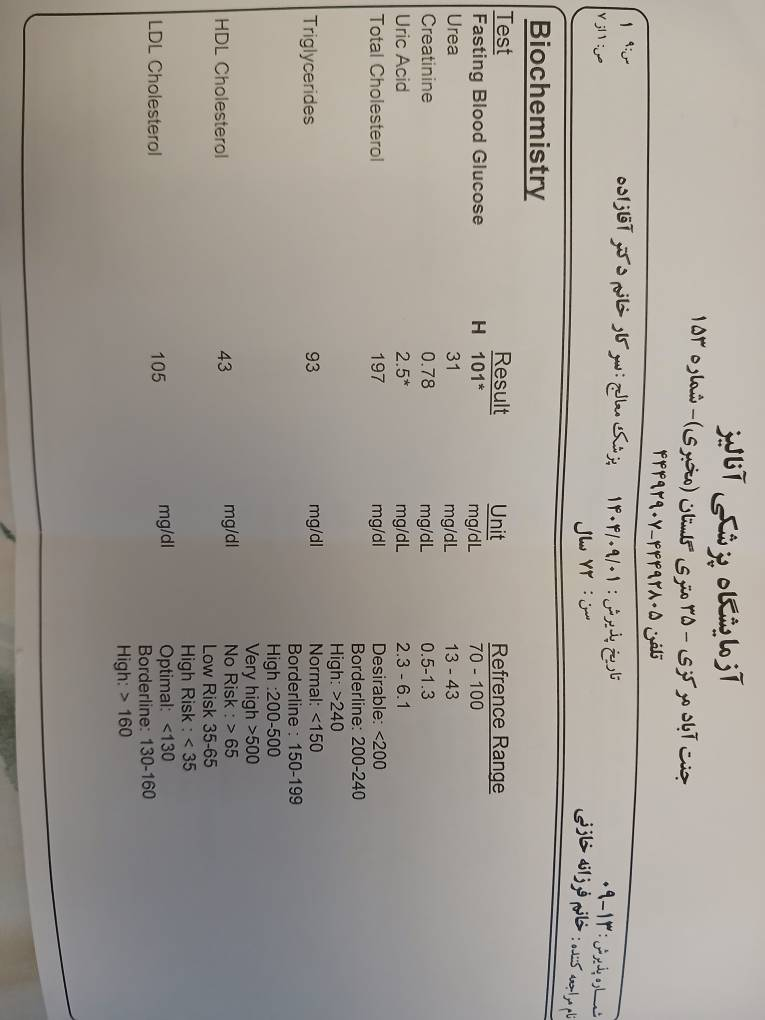

In [37]:
def preview_file(path: Path, width: int = 700):
    from IPython.display import display, Image as IPImage
    from PIL import Image, ImageOps
    import fitz
    path = Path(path)
    if path.suffix.lower() == '.pdf':
        doc = fitz.open(str(path))
        page = doc[0]
        pix = page.get_pixmap(matrix=fitz.Matrix(2, 2), alpha=False)
        tmp = Path(tempfile.gettempdir()) / f'preview_{uuid.uuid4().hex}.png'
        pix.save(str(tmp))
        doc.close()
        display(IPImage(filename=str(tmp), width=width))
    else:
        img = ImageOps.exif_transpose(Image.open(path))
        tmp = Path(tempfile.gettempdir()) / f'preview_{uuid.uuid4().hex}.png'
        img.save(tmp)
        display(IPImage(filename=str(tmp), width=width))

preview_file(SAMPLE_FILE)


## 4. Helper functions for cleaner display


In [38]:
def to_jsonable(obj):
    if obj is None or isinstance(obj, (str, int, float, bool)):
        return obj
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, dict):
        return {k: to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple, set)):
        return [to_jsonable(x) for x in obj]
    if hasattr(obj, 'model_dump'):
        return to_jsonable(obj.model_dump())
    if hasattr(obj, '__dict__'):
        return to_jsonable(obj.__dict__)
    return str(obj)

def pretty(obj, max_chars: int | None = None):
    s = json.dumps(to_jsonable(obj), ensure_ascii=False, indent=2)
    if max_chars and len(s) > max_chars:
        print(s[:max_chars] + '... [truncated]')
    else:
        print(s)

def print_box(title: str):
    print('' + '='*90)
    print(title)
    print('='*90)

def guess_mime(path: Path) -> str:
    ext = path.suffix.lower()
    return {'.pdf':'application/pdf', '.jpg':'image/jpeg', '.jpeg':'image/jpeg', '.png':'image/png', '.webp':'image/webp'}.get(ext, 'application/octet-stream')


## 5. Step-by-step extraction flow on one selected sample

This section directly uses repository services. It helps you find where the failure happens: validation, quality, OCR, relevance, classification, or extraction.


In [39]:
file_name = SAMPLE_FILE.name
mime_type = guess_mime(SAMPLE_FILE)

validator = FileValidationService()
analysis_service = DocumentAnalysisService()
quality_service = QualityService()
preprocess_service = PreprocessingService()
ocr_service = OCRService()
relevance_service = RelevanceService()
classifier = ClassificationService()
common_extractor = CommonFieldExtractor()
lab_extractor = LabExtractor()
rad_extractor = RadiologyExtractor()
pap_extractor = PapSmearExtractor()

print_box('5.1 File validation')
validation = validator.validate(str(SAMPLE_FILE), file_name, mime_type)
pretty(validation)

print_box('5.2 Document analysis')
analysis = analysis_service.analyze(str(SAMPLE_FILE), file_name)
pretty(analysis)

print_box('5.3 Quality assessment')
if getattr(analysis, 'should_skip_image_quality_check', False):
    print('Skipping image quality because this is a text PDF or analysis says skip.')
    quality = None
else:
    quality = quality_service.assess(str(SAMPLE_FILE))
    pretty(quality)


5.1 File validation
{
  "is_valid": true,
  "status": "valid",
  "reason": null
}
5.2 Document analysis
{
  "file_type": "image",
  "pdf_type": null,
  "page_count": 1,
  "has_text_layer": false,
  "estimated_text_length": 0,
  "needs_rendering": false,
  "should_skip_image_quality_check": false,
  "text_sample": ""
}
5.3 Quality assessment
{
  "status": "good_quality",
  "overall_quality_score": 0.764696699307009,
  "is_acceptable": true,
  "issues": [],
  "blur_score": 1.0,
  "brightness_score": 0.7821526951576268,
  "contrast_score": 0.4088246411019346,
  "resolution_score": 0.7803,
  "crop_score": 0.8,
  "orientation_score": 0.8,
  "ocr_readability_score": 0.5,
  "is_fixable": false,
  "metrics": {
    "width": 765,
    "height": 1020,
    "brightness_mean": 154.6666077149814,
    "contrast_std": 32.70597128815477,
    "laplacian_variance": 1434.2302421085724
  },
  "page_scores": [],
  "page_issues": [],
  "worst_page_number": null,
  "average_quality_score": null,
  "min_quality_

In [40]:
print_box('5.4 OCR preparation: render/preprocess if needed')
ocr_paths = []
prep_info = None
render_info = None

with tempfile.TemporaryDirectory(prefix='notebook_flow_') as tmp_dir:
    tmp_dir = Path(tmp_dir)
    if SAMPLE_FILE.suffix.lower() == '.pdf' and not getattr(analysis, 'should_skip_image_quality_check', False):
        render_info = preprocess_service.render_pdf_pages(str(SAMPLE_FILE), max_pages=5, output_dir=str(tmp_dir / 'rendered'))
        pretty(render_info)
        ocr_paths = render_info.output_paths
    elif SAMPLE_FILE.suffix.lower() != '.pdf':
        ocr_paths = [str(SAMPLE_FILE)]

    if not getattr(analysis, 'should_skip_image_quality_check', False):
        q = quality_service.assess_many(ocr_paths) if len(ocr_paths) > 1 else quality_service.assess(ocr_paths[0])
        print('Quality before OCR path selection:')
        pretty(q)
        if q.status != 'good_quality' or 'possible_rotation' in q.issues or 'too_bright' in q.issues:
            print('Trying repository preprocessing because quality/issues suggest it may help...')
            prep_info = preprocess_service.preprocess(str(SAMPLE_FILE), max_pages=5, output_dir=str(tmp_dir / 'processed'))
            pretty(prep_info)
            if prep_info.success and prep_info.output_paths:
                # Keep both original and processed for comparison in the next section.
                comparison_paths = [('original_or_rendered', ocr_paths), ('repo_preprocessed', prep_info.output_paths)]
            else:
                comparison_paths = [('original_or_rendered', ocr_paths)]
        else:
            comparison_paths = [('original_or_rendered', ocr_paths)]
    else:
        comparison_paths = [('text_pdf', [str(SAMPLE_FILE)])]

    print('OCR candidate paths:')
    for label, paths in comparison_paths:
        print(label, paths)


5.4 OCR preparation: render/preprocess if needed
Quality before OCR path selection:
{
  "status": "good_quality",
  "overall_quality_score": 0.764696699307009,
  "is_acceptable": true,
  "issues": [],
  "blur_score": 1.0,
  "brightness_score": 0.7821526951576268,
  "contrast_score": 0.4088246411019346,
  "resolution_score": 0.7803,
  "crop_score": 0.8,
  "orientation_score": 0.8,
  "ocr_readability_score": 0.5,
  "is_fixable": false,
  "metrics": {
    "width": 765,
    "height": 1020,
    "brightness_mean": 154.6666077149814,
    "contrast_std": 32.70597128815477,
    "laplacian_variance": 1434.2302421085724
  },
  "page_scores": [],
  "page_issues": [],
  "worst_page_number": null,
  "average_quality_score": null,
  "min_quality_score": null,
  "num_pages": 1
}
OCR candidate paths:
original_or_rendered ['/Users/aliebrahimi/Documents/Saman Salamat/Extract text from files/Extract-text-from-medical-documents/samples/selected samples/20260427_181919.jpg']


## 6. Notebook-only OCR experiments for selected samples

This is for testing ideas **before changing repository code**.

The current repository OCR often merges all Tesseract words into one huge line. Here we reconstruct visual lines from `pytesseract.image_to_data`, try different PSM modes and rotations, then choose the best candidate by text length + medical/lab signals.


In [41]:
def image_to_pil_variants(path: Path):
    from PIL import Image, ImageOps, ImageEnhance, ImageFilter
    img = ImageOps.exif_transpose(Image.open(path)).convert('RGB')
    variants = []
    variants.append(('original_exif', img))
    # Light enhancement: safer than heavy thresholding.
    gray = ImageOps.grayscale(img)
    auto = ImageOps.autocontrast(gray)
    variants.append(('gray_autocontrast', auto.convert('RGB')))
    # Slight contrast enhancement.
    c = ImageEnhance.Contrast(gray).enhance(1.4)
    variants.append(('gray_contrast_1_4', c.convert('RGB')))
    # Mild sharpen only.
    sh = gray.filter(ImageFilter.SHARPEN)
    variants.append(('gray_sharpen', sh.convert('RGB')))
    return variants

def reconstruct_tesseract_lines(data: dict) -> tuple[str, float]:
    rows = []
    n = len(data.get('text', []))
    for i in range(n):
        txt = str(data['text'][i] or '').strip()
        if not txt:
            continue
        try:
            conf = float(data['conf'][i])
        except Exception:
            conf = -1
        if conf < 0:
            continue
        key = (data.get('block_num', [0]*n)[i], data.get('par_num', [0]*n)[i], data.get('line_num', [0]*n)[i])
        rows.append({
            'key': key,
            'text': txt,
            'left': int(data.get('left', [0]*n)[i]),
            'top': int(data.get('top', [0]*n)[i]),
            'conf': conf,
        })
    grouped = {}
    for r in rows:
        grouped.setdefault(r['key'], []).append(r)
    lines = []
    confs = []
    for key, items in grouped.items():
        items = sorted(items, key=lambda x: x['left'])
        line = ' '.join(x['text'] for x in items).strip()
        if line:
            lines.append((min(x['top'] for x in items), line))
            confs.extend(x['conf'] for x in items)
    lines = [x[1] for x in sorted(lines, key=lambda x: x[0])]
    avg_conf = (sum(confs) / len(confs) / 100.0) if confs else 0.0
    return ''.join(lines), avg_conf

def medical_signal_score(text: str) -> float:
    text_norm = normalize_persian(text or '')
    low = text_norm.lower()
    lab_hits = 0
    for alias in LAB_TEST_ALIASES.keys():
        a = normalize_persian(alias).lower()
        if a and a in low:
            lab_hits += 1
    key_terms = ['آزمایشگاه', 'نتیجه', 'Result', 'Unit', 'Reference', 'CBC', 'WBC', 'RBC', 'TSH', 'FBS', 'سونوگرافی']
    med_hits = sum(1 for k in key_terms if normalize_persian(k).lower() in low)
    nums = len(re.findall(r'\d+(?:\.\d+)?', normalize_digits(text or '')))
    return lab_hits * 3 + med_hits * 2 + min(nums, 50) * 0.2 + min(len(text)/500, 10)

def tesseract_candidate_ocr(path: Path, psm: int = 6, rotate: int = 0, variant_name: str = 'original_exif', img_obj=None):
    import pytesseract
    from PIL import Image
    img = img_obj if img_obj is not None else Image.open(path).convert('RGB')
    if rotate:
        img = img.rotate(rotate, expand=True)
    config = f'--psm {psm}'
    try:
        data = pytesseract.image_to_data(img, lang='eng+fas', config=config, output_type=pytesseract.Output.DICT)
        text, conf = reconstruct_tesseract_lines(data)
        if len(text.strip()) < 20:
            text2 = pytesseract.image_to_string(img, lang='eng+fas', config=config)
            if len(text2.strip()) > len(text.strip()):
                text = text2
                conf = conf or 0.5
        return {
            'variant': variant_name,
            'rotation': rotate,
            'psm': psm,
            'success': bool(text.strip()),
            'text': text,
            'confidence': conf,
            'text_length': len(text),
            'score': medical_signal_score(text),
        }
    except Exception as e:
        return {
            'variant': variant_name,
            'rotation': rotate,
            'psm': psm,
            'success': False,
            'text': '',
            'confidence': 0.0,
            'text_length': 0,
            'score': 0,
            'error': str(e),
        }

def run_notebook_ocr_variants(path: Path, max_candidates: int = 999):
    if path.suffix.lower() == '.pdf':
        return []
    candidates = []
    variants = image_to_pil_variants(path)
    rotations = [0, 90, 180, 270]
    psms = [6, 4, 11]
    for variant_name, img in variants:
        for rot in rotations:
            for psm in psms:
                candidates.append(tesseract_candidate_ocr(path, psm=psm, rotate=rot, variant_name=variant_name, img_obj=img))
                if len(candidates) >= max_candidates:
                    break
            if len(candidates) >= max_candidates:
                break
        if len(candidates) >= max_candidates:
            break
    candidates = sorted(candidates, key=lambda x: (x['score'], x['text_length'], x['confidence']), reverse=True)
    return candidates


In [42]:
print_box('6.1 Run notebook OCR variants on selected image')
if SAMPLE_FILE.suffix.lower() != '.pdf':
    candidates = run_notebook_ocr_variants(SAMPLE_FILE)
    print(f'Generated {len(candidates)} OCR candidates')
    for i, c in enumerate(candidates[:10]):
        print(f"{i:02d} | score={c['score']:.2f} | len={c['text_length']} | conf={c['confidence']:.3f} | variant={c['variant']} | rot={c['rotation']} | psm={c['psm']}")
    BEST_NOTEBOOK_OCR = candidates[0] if candidates else None
    if BEST_NOTEBOOK_OCR:
        print('Best OCR text preview:')
        print(BEST_NOTEBOOK_OCR['text'][:3000])
else:
    print('PDF selected: OCR variants are only for image files. Use repository PDF text extraction instead.')
    BEST_NOTEBOOK_OCR = None


6.1 Run notebook OCR variants on selected image
Generated 48 OCR candidates
00 | score=41.27 | len=534 | conf=0.660 | variant=gray_sharpen | rot=90 | psm=6
01 | score=39.58 | len=488 | conf=0.707 | variant=gray_contrast_1_4 | rot=90 | psm=6
02 | score=39.45 | len=525 | conf=0.712 | variant=gray_autocontrast | rot=90 | psm=6
03 | score=38.78 | len=489 | conf=0.706 | variant=original_exif | rot=90 | psm=6
04 | score=37.97 | len=387 | conf=0.712 | variant=gray_sharpen | rot=90 | psm=4
05 | score=36.93 | len=364 | conf=0.668 | variant=gray_sharpen | rot=90 | psm=11
06 | score=34.99 | len=397 | conf=0.740 | variant=original_exif | rot=90 | psm=11
07 | score=34.76 | len=378 | conf=0.752 | variant=gray_autocontrast | rot=90 | psm=11
08 | score=34.58 | len=388 | conf=0.796 | variant=gray_contrast_1_4 | rot=90 | psm=11
09 | score=29.08 | len=342 | conf=0.797 | variant=gray_contrast_1_4 | rot=90 | psm=4
Best OCR text preview:
آالیز پزشکی آزمایشگاه۱۵۴ شماره (مخبری)- کلستان متری ۳۵ - کزی مر آباد ج

## 7. Current repository full pipeline output

This runs the current stateless `ExtractionPipeline` directly, without API.


In [43]:
pipeline = ExtractionPipeline()
response = pipeline.process(ExtractionInput(
    file_path=str(SAMPLE_FILE),
    file_name=SAMPLE_FILE.name,
    mime_type=guess_mime(SAMPLE_FILE),
    document_id=SAMPLE_FILE.name,
    request_id='notebook-single-' + uuid.uuid4().hex[:8],
    debug=True,
), debug=True)

print_box('Full pipeline response summary')
print('status:', response.status)
print('document_type:', response.document_type)
print('confidence:', response.confidence)
print('errors:', [e.code for e in response.errors])
print('warnings:', [w.code for w in response.warnings])
print('ocr_success:', response.ocr.success if response.ocr else None)
print('ocr_text_length:', response.ocr.text_length if response.ocr else None)

print_box('Common fields')
pretty(response.common_fields, max_chars=6000)

print_box('Extracted data')
pretty(response.extracted_data, max_chars=8000)


Full pipeline response summary
status: ExtractionStatus.LOW_CONFIDENCE
document_type: lab
confidence: 0.561
errors: []
warnings: ['MISSING_LAB_ROWS', 'LOW_EXTRACTION_CONFIDENCE']
ocr_success: True
ocr_text_length: 381
Common fields
{
  "patient_name": {
    "value": "دکتر آقازاده من 1 می: 1 از 7 تاریخ پذیرش : 1304/09/01",
    "hash": null,
    "confidence": 0.85,
    "source_text": "آزمایشگاه پزشکی آنالیز جنت OUT‏ م رکزی - 35 متری کلستان (مخبری)- شماره 153 تلفن 43392907-22392805 پزشک معالج :سر کار خانم دکتر آقازاده من 1 می: 1 از 7 تاریخ پذیرش : 1304/09/01 سن: 72 سال eh polit خانم فرزانه خازنی‎ es, 8 Biochemistry Test 1 Refrence Range Fasting Blood Glucose 70 - 100 Urea 13-3 Creatinine Uric Acid Total Cholesterol Triglycerides HDL Cholesterol LDL Cholesterol",
    "source_line_index": 0,
    "inferred": false,
    "calendar": null
  },
  "national_id": {
    "value": null,
    "hash": null,
    "confidence": 0.0,
    "source_text": null,
    "source_line_index": null,
    "inferred": fa

## 8. Parser debugging with repository OCR and notebook-best OCR

This compares extraction from:

1. the repository pipeline OCR text
2. the notebook-only best OCR variant text

This helps us know whether the problem is OCR or parsing.


In [44]:
repo_ocr_text = ''
if response.debug and isinstance(response.debug, dict):
    repo_ocr_text = response.debug.get('ocr_text') or ''

texts_to_test = []
if repo_ocr_text:
    texts_to_test.append(('repository_pipeline_ocr', repo_ocr_text))
if BEST_NOTEBOOK_OCR and BEST_NOTEBOOK_OCR.get('text'):
    texts_to_test.append(('notebook_best_ocr_variant', BEST_NOTEBOOK_OCR['text']))

for label, text in texts_to_test:
    print_box(f'Parser test: {label}')
    cls = classifier.classify(text)
    common = common_extractor.extract_structured(text)
    labs = lab_extractor.extract(text)
    rad = rad_extractor.extract(text)
    print('classification:', cls)
    print('common patient/date/age/sex/center:')
    for k in ['patient_name','national_id','date_of_test_or_report','center_name','doctor_name','age','sex','tracking_number']:
        print(k, '=>', common.get(k))
    print('lab row count:', len(labs))
    for r in labs[:30]:
        print(r)
    if cls.document_type == 'radiology':
        print('radiology:', rad)


Parser test: repository_pipeline_ocr
classification: ClassificationResult(document_type='lab', confidence=0.6, matched_signals=['AST', 'Biochemistry', 'آزمایشگاه'], reason='Matched 3 lab signal(s)')
common patient/date/age/sex/center:
patient_name => {'value': 'دکتر آقازاده من 1 می: 1 از 7 تاریخ پذیرش : 1304/09/01', 'confidence': 0.85, 'source_text': 'آزمایشگاه پزشکی آنالیز جنت OUT\u200f م رکزی - 35 متری کلستان (مخبری)- شماره 153 تلفن 43392907-22392805 پزشک معالج :سر کار خانم دکتر آقازاده من 1 می: 1 از 7 تاریخ پذیرش : 1304/09/01 سن: 72 سال eh polit خانم فرزانه خازنی\u200e es, 8 Biochemistry Test 1 Refrence Range Fasting Blood Glucose 70 - 100 Urea 13-3 Creatinine Uric Acid Total Cholesterol Triglycerides HDL Cholesterol LDL Cholesterol', 'source_line_index': 0}
national_id => {'value': None, 'hash': None, 'confidence': 0.0, 'source_text': None, 'source_line_index': None}
date_of_test_or_report => {'value': '1304/09/01', 'confidence': 0.9, 'source_text': 'آزمایشگاه پزشکی آنالیز جنت OUT\

## 9. Alias-window finder for messy OCR

This does not replace the real extractor. It is a debug tool to show which lab aliases are present in OCR and what text appears around them.


In [45]:
def alias_windows(text: str, window: int = 120, max_hits: int = 80):
    norm = normalize_persian(normalize_digits(text or ''))
    low = norm.lower()
    hits = []
    aliases = sorted(LAB_TEST_ALIASES.keys(), key=len, reverse=True)
    for alias in aliases:
        a = normalize_persian(alias).lower()
        if not a or len(a) < 2:
            continue
        start = 0
        while True:
            idx = low.find(a, start)
            if idx == -1:
                break
            snippet = norm[max(0, idx-40): idx + len(a) + window]
            nums = re.findall(r'[*<>]?\d+(?:\.\d+)?', snippet)
            hits.append({
                'alias': alias,
                'standard': LAB_TEST_ALIASES.get(alias),
                'index': idx,
                'numbers_nearby': nums[:8],
                'snippet': snippet,
            })
            start = idx + len(a)
            if len(hits) >= max_hits:
                return hits
    return hits

for label, text in texts_to_test[:2]:
    print_box(f'Alias windows: {label}')
    hits = alias_windows(text)
    print('hits:', len(hits))
    for h in hits[:40]:
        print('---', h['alias'], '=>', h['standard'], 'nums:', h['numbers_nearby'])
        print(h['snippet'])


Alias windows: repository_pipeline_ocr
hits: 11
--- Triglycerides => Triglycerides nums: []
 Creatinine Uric Acid Total Cholesterol Triglycerides HDL Cholesterol LDL Cholesterol
--- Cholesterol => Cholesterol nums: ['00', '13', '3']
00 Urea 13-3 Creatinine Uric Acid Total Cholesterol Triglycerides HDL Cholesterol LDL Cholesterol
--- Cholesterol => Cholesterol nums: []
cid Total Cholesterol Triglycerides HDL Cholesterol LDL Cholesterol
--- Cholesterol => Cholesterol nums: []
terol Triglycerides HDL Cholesterol LDL Cholesterol
--- Creatinine => Creatinine nums: ['70', '100', '13', '3']
asting Blood Glucose 70 - 100 Urea 13-3 Creatinine Uric Acid Total Cholesterol Triglycerides HDL Cholesterol LDL Cholesterol
--- Uric Acid => Uric Acid nums: ['70', '100', '13', '3']
d Glucose 70 - 100 Urea 13-3 Creatinine Uric Acid Total Cholesterol Triglycerides HDL Cholesterol LDL Cholesterol
--- Glucose => FBS nums: ['1', '70', '100', '13', '3']
try Test 1 Refrence Range Fasting Blood Glucose 70 - 100 

## 10. Batch test selected samples

This runs the current repository pipeline on all selected samples, with `debug=True` by default so OCR text is available in the JSON outputs.

Outputs are saved to:

```text
notebook_outputs/selected_samples_flow/
```


In [46]:
BATCH_LIMIT = None  # set to an integer like 10 for quick testing
DEBUG_BATCH = True
OUTPUT_DIR = REPO_ROOT / 'notebook_outputs' / 'selected_samples_flow'
JSON_DIR = OUTPUT_DIR / 'json'
OCR_DIR = OUTPUT_DIR / 'ocr'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
JSON_DIR.mkdir(parents=True, exist_ok=True)
OCR_DIR.mkdir(parents=True, exist_ok=True)

batch_files = sample_files[:BATCH_LIMIT] if BATCH_LIMIT else sample_files
print('Batch files:', len(batch_files))


Batch files: 20


In [47]:
def summarize_response(file_path: Path, response) -> dict:
    data = to_jsonable(response)
    common = data.get('common_fields') or {}
    extracted = data.get('extracted_data') or {}
    labs = extracted.get('lab_results') or []
    rad = extracted.get('radiology') or {}
    pap = extracted.get('pap_smear') or {}
    ocr = data.get('ocr') or {}
    quality = data.get('quality') or {}
    errors = data.get('errors') or []
    warnings = data.get('warnings') or []
    return {
        'filename': file_path.name,
        'status': data.get('status'),
        'document_type': data.get('document_type'),
        'confidence': data.get('confidence'),
        'quality_status': quality.get('status'),
        'quality_score': quality.get('overall_quality_score'),
        'quality_issues': '|'.join(quality.get('issues') or []),
        'ocr_success': ocr.get('success'),
        'ocr_confidence': ocr.get('confidence'),
        'ocr_text_length': ocr.get('text_length'),
        'patient_name_found': bool((common.get('patient_name') or {}).get('value')),
        'patient_name_value': (common.get('patient_name') or {}).get('value'),
        'date_found': bool((common.get('date_of_test_or_report') or {}).get('value')),
        'date_value': (common.get('date_of_test_or_report') or {}).get('value'),
        'center_name_found': bool((common.get('center_name') or {}).get('value')),
        'age_found': bool((common.get('age') or {}).get('value') is not None),
        'age_value': (common.get('age') or {}).get('value'),
        'sex_found': bool((common.get('sex') or {}).get('value')),
        'sex_value': (common.get('sex') or {}).get('value'),
        'national_id_hash_found': bool((common.get('national_id') or {}).get('hash')),
        'lab_result_count': len(labs),
        'radiology_has_narrative': bool(rad.get('full_narrative_report')) if isinstance(rad, dict) else False,
        'pap_smear_found': bool(pap) if isinstance(pap, dict) else False,
        'error_codes': '|'.join(e.get('code','') for e in errors),
        'warning_codes': '|'.join(w.get('code','') for w in warnings),
    }

def write_text(path: Path, text: str):
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(text or '', encoding='utf-8')

rows = []
pipeline = ExtractionPipeline()

for idx, fp in enumerate(batch_files, 1):
    print(f'[{idx}/{len(batch_files)}] {fp.name}')
    resp = pipeline.process(ExtractionInput(
        file_path=str(fp),
        file_name=fp.name,
        mime_type=guess_mime(fp),
        document_id=fp.name,
        request_id=f'notebook-selected-{idx:04d}-{uuid.uuid4().hex[:6]}',
        debug=DEBUG_BATCH,
    ), debug=DEBUG_BATCH)
    data = to_jsonable(resp)
    out_json = JSON_DIR / f'{idx:04d}_{fp.stem}.json'
    out_json.write_text(json.dumps(data, ensure_ascii=False, indent=2), encoding='utf-8')
    ocr_text = ''
    if data.get('debug') and isinstance(data['debug'], dict):
        ocr_text = data['debug'].get('ocr_text') or ''
    write_text(OCR_DIR / f'{idx:04d}_{fp.stem}.txt', ocr_text)
    rows.append(summarize_response(fp, resp))

summary_path = OUTPUT_DIR / 'summary.csv'
with summary_path.open('w', encoding='utf-8-sig', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
    writer.writeheader()
    writer.writerows(rows)

print('Saved:', summary_path)
print('JSON dir:', JSON_DIR)
print('OCR dir:', OCR_DIR)


[1/20] 20260427_181919.jpg
[2/20] ۲۰۲۶۰۴۲۸_۱۵۰۱۰۶.jpg
[3/20] 0014161672_14041209_O_00404121721.pdf
[4/20] ۲۰۲۶۰۴۲۵_۲۲۰۷۰۰.jpg
[5/20] 20260427_181713.jpg
[6/20] 0021858845_14041209_O_00404121731.pdf
[7/20] -2147483648_-210195.jpg
[8/20] 0023471026_14041209_O_00404121728.pdf
[9/20] 0025631314_14041209_O_00404121726.pdf
[10/20] -2147483648_-210193.jpg
[11/20] ۲۰۲۶۰۴۲۸_۱۵۰۲۲۸.jpg
[12/20] 0024150010_14041209_O_00404121722.pdf
[13/20] 20260427_181636.jpg
[14/20] 20260427_181554.jpg
[15/20] 0025692283_14041209_O_00404121730.pdf
[16/20] ۲۰۲۶۰۴۲۸_۱۵۰۰۳۶.jpg
[17/20] ۲۰۲۶۰۴۲۸_۱۵۰۰۵۱.jpg
[18/20] 0020139871_14041209_O_00404121714.pdf
[19/20] 20260427_181654.jpg
[20/20] ۲۰۲۶۰۴۲۸_۱۵۰۱۲۰.jpg
Saved: /Users/aliebrahimi/Documents/Saman Salamat/Extract text from files/Extract-text-from-medical-documents/notebook_outputs/selected_samples_flow/summary.csv
JSON dir: /Users/aliebrahimi/Documents/Saman Salamat/Extract text from files/Extract-text-from-medical-documents/notebook_outputs/selected_samples_flow/js

In [48]:
# Show batch metrics.
from collections import Counter

print_box('Batch summary')
print('Total:', len(rows))
for col in ['status', 'document_type', 'quality_status', 'ocr_success']:
    print(col, Counter(r[col] for r in rows))
print('patient_name_found:', sum(bool(r['patient_name_found']) for r in rows), '/', len(rows))
print('date_found:', sum(bool(r['date_found']) for r in rows), '/', len(rows))
print('files with lab_result_count > 0:', sum(int(r['lab_result_count']) > 0 for r in rows), '/', len(rows))
print('total extracted lab rows:', sum(int(r['lab_result_count']) for r in rows))

print('Worst cases:')
for r in rows:
    if r['status'] in {'ocr_failed', 'unrelated_document'} or (r['document_type']=='lab' and int(r['lab_result_count'])==0):
        print(r['filename'], '| status=', r['status'], '| type=', r['document_type'], '| ocr_len=', r['ocr_text_length'], '| lab_rows=', r['lab_result_count'], '| warnings=', r['warning_codes'])


Batch summary
Total: 20
status Counter({<ExtractionStatus.LOW_CONFIDENCE: 'low_confidence'>: 10, <ExtractionStatus.SUCCESS: 'success'>: 7, <ExtractionStatus.OCR_FAILED: 'ocr_failed'>: 2, <ExtractionStatus.UNRELATED_DOCUMENT: 'unrelated_document'>: 1})
document_type Counter({'lab': 17, 'unknown_medical': 2, 'unrelated_document': 1})
quality_status Counter({'good_quality': 8, None: 7, 'needs_preprocessing': 5})
ocr_success Counter({True: 18, False: 2})
patient_name_found: 9 / 20
date_found: 11 / 20
files with lab_result_count > 0: 7 / 20
total extracted lab rows: 60
Worst cases:
20260427_181919.jpg | status= ExtractionStatus.LOW_CONFIDENCE | type= lab | ocr_len= 381 | lab_rows= 0 | warnings= MISSING_LAB_ROWS|LOW_EXTRACTION_CONFIDENCE
۲۰۲۶۰۴۲۸_۱۵۰۱۰۶.jpg | status= ExtractionStatus.LOW_CONFIDENCE | type= lab | ocr_len= 589 | lab_rows= 0 | warnings= MISSING_LAB_ROWS|MISSING_PATIENT_NAME|MISSING_REPORT_DATE|LOW_EXTRACTION_CONFIDENCE
۲۰۲۶۰۴۲۵_۲۲۰۷۰۰.jpg | status= ExtractionStatus.LOW_CONFIDEN